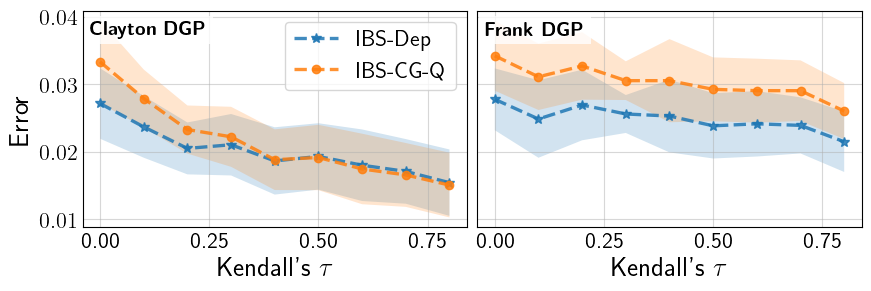

In [ ]:
import numpy as np
import pandas as pd
import config as cfg
from matplotlib import pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# Load CG-Q ablation results
filename = f"{cfg.RESULTS_DIR}/synthetic_results_bguw_vs_cgq.csv"
df = pd.read_csv(filename)

# Metric column names
metric1, metric2 = "err_bguw", "err_cgq"
label1, label2 = r"IBS-Dep", r"IBS-CG-Q"

# Fallbacks if saved under different names
if metric1 not in df.columns:
    metric1 = "err_dep_bguw"
if metric2 not in df.columns:
    metric2 = "err_dep_cgq"

sigma_level = 1.0
copula_order = ["clayton", "frank"]

# Aggregate within each copula over seeds
grouped = (
    df.groupby(["copula_name", "k_tau"], as_index=False)
      .agg(
          bguw_mean=(metric1, "mean"),
          bguw_std=(metric1, "std"),
          cgq_mean=(metric2, "mean"),
          cgq_std=(metric2, "std"),
      )
      .sort_values(["copula_name", "k_tau"])
)

# Plot: split by copula
fig, axs = plt.subplots(1, 2, figsize=(8.6, 2.8), sharey=True, constrained_layout=True)

for ax, copula in zip(axs, copula_order):
    sub = grouped[grouped["copula_name"] == copula].copy()

    x = sub["k_tau"].to_numpy()

    m1 = sub["bguw_mean"].to_numpy()
    s1 = sub["bguw_std"].to_numpy()

    m2 = sub["cgq_mean"].to_numpy()
    s2 = sub["cgq_std"].to_numpy()

    ax.plot(
        x, m1,
        linestyle="dashed",
        marker="*",
        markersize=7,
        linewidth=2.4,
        alpha=0.85,
        label=label1,
    )
    ax.plot(
        x, m2,
        linestyle="dashed",
        marker="o",
        markersize=6,
        linewidth=2.4,
        alpha=0.85,
        label=label2,
    )

    if np.any(~np.isnan(s1)):
        ax.fill_between(x, m1 - sigma_level * s1, m1 + sigma_level * s1, alpha=0.2)
    if np.any(~np.isnan(s2)):
        ax.fill_between(x, m2 - sigma_level * s2, m2 + sigma_level * s2, alpha=0.2)

    pretty_name = "Clayton DGP" if copula == "clayton" else "Frank DGP"
    ax.text(
        0.02, 0.95,
        rf"\textbf{{{pretty_name}}}",
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_xlabel(r"Kendall's $\tau$")
    ax.set_xticks([0.0, 0.25, 0.5, 0.75])
    ax.set_xticklabels(["0.00", "0.25", "0.50", "0.75"])

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)
    ax.grid(True, alpha=0.5)

axs[0].set_ylabel(r"Error")
axs[0].legend(loc="upper right", frameon=True)

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_bguw_vs_cgq_by_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()